# Curvas de desempenho × limiar de classificação

Gera uma figura única (`perf_curves_threshold.png`) com as curvas de *recall*, *precision* e F1 em função do limiar de classificação, para Maceió e Arapiraca, nas variantes tradicional (célula a célula) e com tolerância espacial (vizinhança de Chebyshev $\leq 1$).

**Entrada:** `./output/{cidade}/perf_thrs/convlstm_perf_thrs_{cidade}_42.pkl`

**Saída:** `./crime_deeping_learning/figuras/perf_curves_threshold.png`

Layout: $2 \times 2$ (linhas = cidade, colunas = variante). Cada subplot mostra três curvas (*recall*, *precision*, F1) e uma linha tracejada vertical no limiar que maximiza o F1 da variante.

## 1. Carregamento dos dados

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("./crime_deeping_learning/figuras")
FIG_DIR.mkdir(parents=True, exist_ok=True)

COLS = ["threshold", "recall", "precision", "f1", "recall_sp", "precision_sp", "f1_sp"]

def load_perf(city):
    with open(f"./output/{city}/perf_thrs/convlstm_perf_thrs_{city}_42.pkl", "rb") as f:
        rows = pickle.load(f)
    return pd.DataFrame(rows, columns=COLS)

df_mac = load_perf("maceio")
df_ara = load_perf("arapiraca")

for name, df in [("Maceió", df_mac), ("Arapiraca", df_ara)]:
    i_trad = df["f1"].idxmax()
    i_sp = df["f1_sp"].idxmax()
    print(f"{name}: F1 tradicional ótimo = {df.loc[i_trad, 'f1']:.4f} em τ = {df.loc[i_trad, 'threshold']:.2f}")
    print(f"{name}: F1 espacial    ótimo = {df.loc[i_sp,   'f1_sp']:.4f} em τ = {df.loc[i_sp,   'threshold']:.2f}")

Maceió: F1 tradicional ótimo = 0.0476 em τ = 0.75
Maceió: F1 espacial    ótimo = 0.2405 em τ = 0.68
Arapiraca: F1 tradicional ótimo = 0.0379 em τ = 0.74
Arapiraca: F1 espacial    ótimo = 0.2063 em τ = 0.62


## 2. Plot 2×2

Figura salva em: crime_deeping_learning/figuras/perf_curves_threshold.png


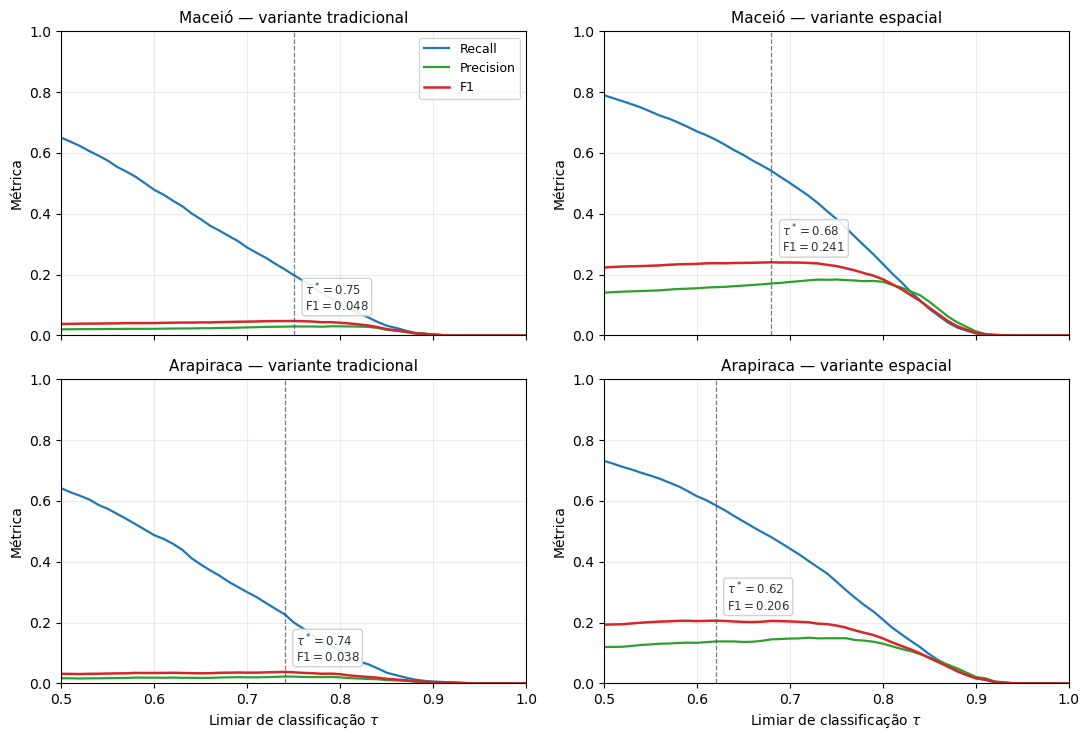

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True)

configs = [
    (0, 0, df_mac, "Maceió",    "tradicional", ("recall",    "precision",    "f1")),
    (0, 1, df_mac, "Maceió",    "espacial",    ("recall_sp", "precision_sp", "f1_sp")),
    (1, 0, df_ara, "Arapiraca", "tradicional", ("recall",    "precision",    "f1")),
    (1, 1, df_ara, "Arapiraca", "espacial",    ("recall_sp", "precision_sp", "f1_sp")),
]

color_recall    = "#1f77b4"
color_precision = "#2ca02c"
color_f1        = "#d62728"

for r, c, df, city, variant, (k_r, k_p, k_f) in configs:
    ax = axes[r, c]
    ax.plot(df["threshold"], df[k_r], label="Recall",    color=color_recall,    linewidth=1.6)
    ax.plot(df["threshold"], df[k_p], label="Precision", color=color_precision, linewidth=1.6)
    ax.plot(df["threshold"], df[k_f], label="F1",        color=color_f1,        linewidth=1.8)
    
    # Linha vertical no τ que maximiza o F1 dessa variante
    i_best = df[k_f].idxmax()
    tau_best = df.loc[i_best, "threshold"]
    f1_best = df.loc[i_best, k_f]
    ax.axvline(tau_best, color="#444444", linestyle="--", linewidth=0.9, alpha=0.7)
    ax.annotate(
        f"$\\tau^* = {tau_best:.2f}$\nF1$ = {f1_best:.3f}$",
        xy=(tau_best, f1_best),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=8.5,
        color="#333333",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#cccccc", alpha=0.9),
    )

    ax.set_title(f"{city} — variante {variant}", fontsize=11)
    ax.set_ylabel("Métrica", fontsize=10)
    if r == 1:
        ax.set_xlabel("Limiar de classificação $\\tau$", fontsize=10)
    ax.set_xlim(0.5, 1.0)
    ax.set_ylim(0, 1.0)
    ax.grid(alpha=0.25)
    if r == 0 and c == 0:
        ax.legend(loc="upper right", frameon=True, fontsize=9)

fig.tight_layout()
out_path = FIG_DIR / "perf_curves_threshold.png"
fig.savefig(out_path, dpi=140, bbox_inches="tight")
print(f"Figura salva em: {out_path}")
plt.show()